# 항공사 고객 만족도 예측 모델 구축 및 서비스 항목별 투자 우선순위 분석

## 문제 상황
항공사는 예산이 한정되어 있다. 기내식, 좌석, 와이파이, 온라인 체크인 등 승객이 불편을 느끼는 요소는 많지만, 이를 전부 동시에 개선할 수는 없다.

> **한정된 예산으로 승객의 불만족을 개선하려면, 여러 서비스 요소 중 어디를 먼저 건드려야 하는가?**

이 질문에 답하려면 단순히 "가장 불편해하는 항목이 무엇인가"만 봐서는 안 된다.

1. **많은 승객이 불편하다고 느끼지만, 개선해도 만족도 상승 효과가 크지 않은 항목**이 있을 수 있다. (다른 요인 때문에 불만족이 이미 고착되었거나, 항공사 통제 밖의 요인과 얽혀 있는 경우)
2. **가장 큰 불편 요소는 아니지만, 개선했을 때 만족도가 크게 뛰어오르는 항목**이 있을 수 있다. (소수만 겪는 문제지만 그 소수에게는 결정적인 항목)

이 프로젝트는 이 두 케이스를 구분해내고, "어디에 투자하면 실제로 만족도가 얼마나 오르는가"를 예측 모델 기반 시뮬레이션으로 알아내보고자 한다.


## 진행 순서
1. 데이터 분석
2. 승객 분포 파악 (PCA + K-means)
3. 만족도 예측 모델 구축 (Random Forest)
4. 무엇이 만족도를 좌우하는가
5. 투자 우선순위 — 불만율 × 개선효과
6. 예측 모델을 이용한 투자 전후 시뮬레이션
7. 결론


## 1. 데이터 분석

**Airline Passenger Satisfaction** (Kaggle) — https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

- 승객 수: 25,976명
- 서비스 만족도 14개 항목 (0~5점 척도): 와이파이, 온라인 예약, 게이트 위치, 기내식, 온라인 탑승, 좌석 편의성, 기내 엔터테인먼트, 승무원 서비스, 다리 공간, 수하물 처리, 체크인, 기내 서비스, 청결도, 도착/출발 시간 편의성
- 승객 특성: 성별, 고객 등급(단골/비단골), 여행 목적(비즈니스/개인), 좌석 등급(비즈니스/이코노미), 나이, 비행 거리
- 운항 정보: 출발/도착 지연 시간(분)
- 타겟 변수: `satisfaction` — 최종 만족(satisfied) / 불만족(neutral or dissatisfied)

.

In [156]:
#데이터 업로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')


import matplotlib as mpl
import subprocess

def setup_korean_font():
    candidates = [
        os.path.join(os.getcwd(), 'NotoSansKR.ttf'),
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    ]
    for path in candidates:
        if os.path.exists(path):
            try:
                fm.fontManager.addfont(path)
                name = fm.FontProperties(fname=path).get_name()
                return name
            except Exception:
                continue

    try:
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            return fm.FontProperties(fname=path).get_name()
    except Exception:
        pass
    return None

_font_name = setup_korean_font()
if _font_name:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [_font_name] + plt.rcParams['font.sans-serif']
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('figs', exist_ok=True)


In [157]:
display(df.head())
#데이터 확인

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [158]:
print('결측치 확인:')
display(df.isnull().sum())

결측치 확인:


,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


feature 중 승객 특성 항목(성별·나이·여행 목적·좌석 등급 등)은 항공사가 "투자"로 바꿀 수 없는 구조적 변수이므로, 본 분석은 항공사가 실제로 개선 가능한 14개 서비스 항목에 집중한다.

In [159]:
#불필요한 feature분리
df = pd.read_csv('airline_satisfaction.csv').drop(columns=['Unnamed: 0', 'id'])
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Inflight service', 'Cleanliness']



##  사용할 Feature 목록(총 14개)

| Feature                         | 설명                               |
|:--------------------------------|:-----------------------------------|
| Inflight wifi service         | 기내 와이파이 서비스 만족도         |
| Departure/Arrival time convenient | 출발/도착 시간 편의성 만족도     |
| Ease of Online booking        | 온라인 예약 편의성 만족도          |
| Gate location                 | 게이트 위치 만족도                 |
| Food and drink                | 기내식 및 음료 만족도              |
| Online boarding               | 온라인 탑승 수속 만족도            |
| Seat comfort                  | 좌석 편의성 만족도                 |
| Inflight entertainment        | 기내 엔터테인먼트 만족도           |
| On-board service              | 기내 서비스 만족도                 |
| Leg room service              | 다리 공간 만족도                   |
| Baggage handling             | 수하물 처리 만족도                 |
| Checkin service               | 체크인 서비스 만족도               |
| Inflight service              | 비행 중 서비스 만족도              |
| Cleanliness                  | 청결도 만족도                      |

## 2. 승객 분포 파악 — PCA + K-means

14개 항목을 개별적으로 보기 전에, 승객들이 서비스에 대해 전반적으로 어떻게 갈려 있는지 먼저 확인한다.

In [160]:
#pca
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[service_cols])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
print('2개 주성분 설명 분산 비율:', np.round(pca.explained_variance_ratio_, 3),
      '(합:', round(pca.explained_variance_ratio_.sum(), 3), ')')

loadings = pd.DataFrame(pca.components_.T, index=service_cols, columns=['PC1', 'PC2'])
print('\nPC1 상위 항목:')
print(loadings['PC1'].sort_values(key=abs, ascending=False).head(4).round(2))
print('\nPC2 상위 항목:')
print(loadings['PC2'].sort_values(key=abs, ascending=False).head(4).round(2))


2개 주성분 설명 분산 비율: [0.27  0.172] (합: 0.442 )

PC1 상위 항목:
Inflight entertainment    0.43
Cleanliness               0.36
Seat comfort              0.35
Food and drink            0.31
Name: PC1, dtype: float64

PC2 상위 항목:
Ease of Online booking               0.53
Inflight wifi service                0.45
Gate location                        0.43
Departure/Arrival time convenient    0.42
Name: PC2, dtype: float64


PC1축은 물리적으로 개선 가능한 항목
PC2축은 물리적 X , 디지털/예약/시간 측면에서의 편의 항목들이 몰려있음

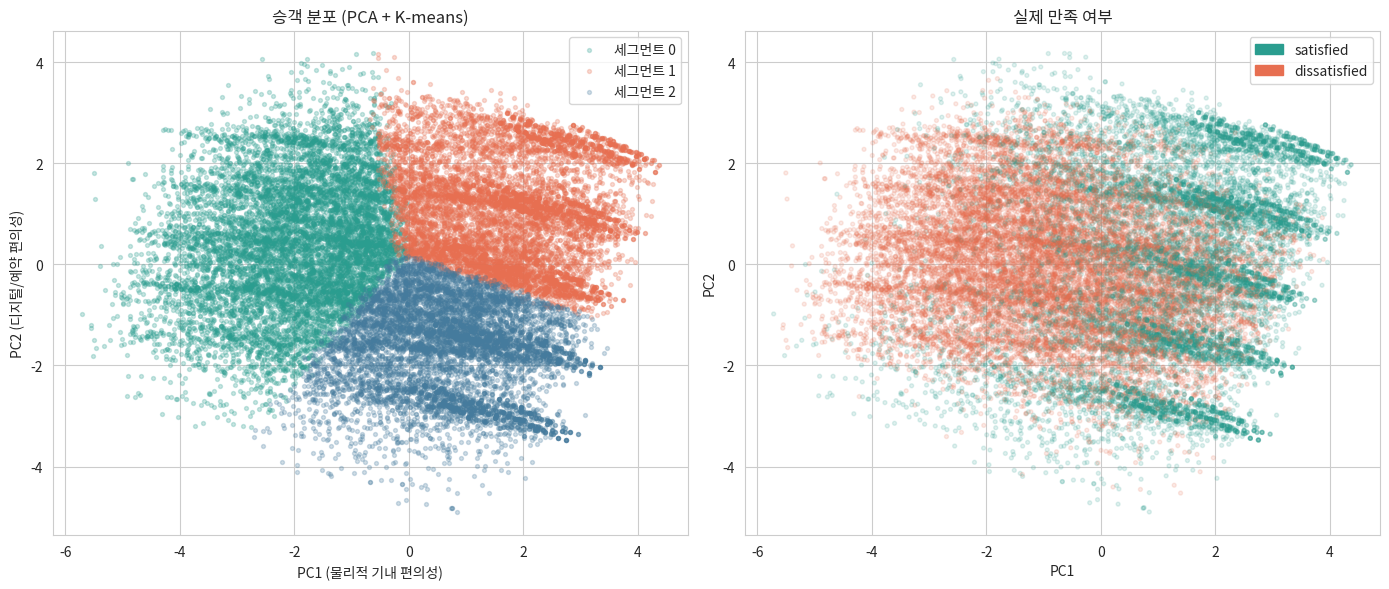

In [161]:
#k-means
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df['segment'] = km.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2a9d8f', '#e76f51', '#457b9d']
for seg in sorted(df['segment'].unique()):
    mask = df['segment'] == seg
    axes[0].scatter(pcs[mask, 0], pcs[mask, 1], s=8, alpha=0.25, color=colors[seg], label=f'세그먼트 {seg}')
axes[0].set_xlabel('PC1 (물리적 기내 편의성)')
axes[0].set_ylabel('PC2 (디지털/예약 편의성)')
axes[0].set_title('승객 분포 (PCA + K-means)')
axes[0].legend()

sat_colors = df['satisfaction'].map({'satisfied': '#2a9d8f', 'neutral or dissatisfied': '#e76f51'})
axes[1].scatter(pcs[:, 0], pcs[:, 1], s=8, alpha=0.15, c=sat_colors)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('실제 만족 여부')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2a9d8f', label='satisfied'), Patch(color='#e76f51', label='dissatisfied')])
plt.tight_layout()
plt.savefig('figs/01_distribution.png', dpi=120)
plt.show()

 **분포 해석:**  승객들이 서비스에 대해 뚜렷하게 그룹핑 되진 않지만,오른쪽 그래프를 보면 만족/불만족이 PC1 축을 따라 상당히 갈리는 것을 알 수 있다. 다만 이 두 축만으로는 "어떤 항목을 개선해야 하는지"까지는 알 수 없으므로, 예측 모델을 통해 항목별 영향력을 확인한다



In [162]:
seg_summary = pd.DataFrame({
    '인원수': df.groupby('segment').size(),
    '비율(%)': (df.groupby('segment').size() / len(df) * 100).round(1),
    '만족비율(%)': (df.groupby('segment')['satisfaction'].apply(lambda x: (x == 'satisfied').mean()) * 100).round(1),
})
seg_summary


,인원수,비율(%),만족비율(%)
segment,,,
0,9708,37.4,14.0
1,8493,32.7,71.2
2,7775,29.9,51.5


## 3. 만족도 예측 모델 구축 — Random Forest


In [163]:
#데이터 셋 분리
X = df[service_cols]
y = (df['satisfaction'] == 'satisfied').astype(int)
#training/test= 7.5:2.5
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
#랜덤포레스트 학습(개수 300개)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f'accuracy: {acc:.3f}')
print(classification_report(y_test, pred, target_names=['dissatisfied', 'satisfied']))


accuracy: 0.927
              precision    recall  f1-score   support

dissatisfied       0.94      0.93      0.93      3643
   satisfied       0.91      0.92      0.92      2851

    accuracy                           0.93      6494
   macro avg       0.93      0.93      0.93      6494
weighted avg       0.93      0.93      0.93      6494



학습을 진행하니 대략 91-92% 정확도로 만족 여부를 예측할 수 있음.

이정도면 "어떤 항목이 중요한가","이 항목을 개선하면 만족률이 얼마나 오르는가"같은 지표를 확인하는 도구로 신뢰하고 사용할 수 있을 것으로 보임

## 4. 무엇이 만족도를 가장 크게 좌우하는가

총 14개의 feature들 중 어떤것이 가장 크게 만족도에 영향을 미치는 지 알아보자

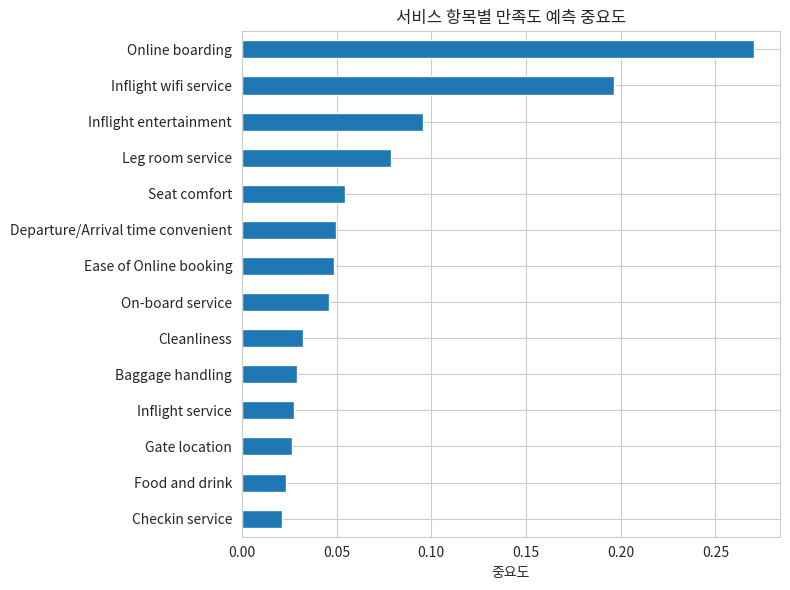

,0
Online boarding,0.270549
Inflight wifi service,0.196329
Inflight entertainment,0.095563
Leg room service,0.078650
Seat comfort,0.054673
Departure/Arrival time convenient,0.049815
Ease of Online booking,0.048811
On-board service,0.045935
Cleanliness,0.032387
Baggage handling,0.029017


In [164]:
importance = pd.Series(rf.feature_importances_, index=service_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('중요도')
ax.set_title('서비스 항목별 만족도 예측 중요도')
plt.tight_layout()
plt.savefig('figs/02_importance.png', dpi=120)
plt.show()

importance


Online boarding(온라인 탑승 수속), Inflight wifi service(기내 와이파이), Leg room service(다리 공간)가 상위권이다.

하지만 이 중요도만으로 투자 우선순위를 정하면 안 된다. 중요도가 높아도 **이미 많은 승객이 만족하고 있는 항목**이라면 추가 투자의 실익이 작을 수 있고, 반대로 중요도가 상대적으로 낮아도 **개선했을 때 실제 전환 효과가 큰 항목**이라면 우선순위가 높아질 수 있다.

## 5. 투자 우선순위 — 불만율 × 개선효과

문제 상황에서 제기한 두 가지 축을 계산한다.

>1. **많은 승객이 불편하다고 느끼지만, 개선해도 만족도 상승 효과가 크지 않은 항목**

>불만율 높음/ 개선효과 낮음

>2. **가장 큰 불편 요소는 아니지만, 개선했을 때 만족도가 크게 뛰어오르는 항목**

>불만율 낮음/개선효과 높음

- **불만율**: 현재 해당 항목에 낮은 점수(0~2점)를 준 승객의 비율. "얼마나 많은 사람이 불편해하는가."
- **개선효과**: 예측 모델(random forest)을 이용해, 해당 항목의 점수를 낮은 수준(1점)에서 양호한 수준(4점)으로 올렸을 때 **예측 만족 확률이 평균적으로 얼마나 상승하는지**를 계산한 값 (Partial Dependence 방식). "실제로 개선했을 때 효과가 얼마나 큰가."


In [165]:
unhappy_rate = (df[service_cols] <= 2).mean() * 100
# 평점이 2점보다 낮은 경우를 불만족이라고 기준
effects = {}
#아까 만든 모델을 이용해서 가상으로 해당 항목의 점수를 투자했다고 가정하고 1->4점으로 바꿔서 다시 만족도를 예측했을 때 나올 확률
for col in service_cols:
    X_low = X_test.copy(); X_low[col] = 1
    X_high = X_test.copy(); X_high[col] = 4#1->4점으로 바꿔서 계산
    p_low = rf.predict_proba(X_low)[:, 1].mean()
    p_high = rf.predict_proba(X_high)[:, 1].mean()
    effects[col] = (p_high - p_low) * 100

effect = pd.Series(effects)

matrix_df = pd.DataFrame({'불만율(%)': unhappy_rate, '개선효과(%p)': effect}).round(2)
matrix_df.sort_values('개선효과(%p)', ascending=False)


,불만율(%),개선효과(%p)
Online boarding,29.45,18.66
Inflight wifi service,45.39,18.23
Leg room service,29.58,11.28
Inflight entertainment,29.00,9.08
On-board service,25.36,6.03
Food and drink,33.24,3.82
Baggage handling,17.83,3.66
Inflight service,17.83,3.63
Seat comfort,25.66,3.52
Cleanliness,28.46,3.10


 `Gate location`(게이트 위치), `Departure/Arrival time convenient`(출발/도착 시간 편의성)는 개선효과가 음수로 나온다.

  이는 점수를 올려도(1->4점으로 변경한 것) 모델이 예측하는 만족 확률이 거의 오르지 않는다는 뜻으로, 항공사가 점수 자체를 올린다고 해서 만족도가 따라 오르지 않는 항목일 수 있다고 본다. (다른 요인과 얽혀 있거나, 애초에 만족도와 약한 관계).

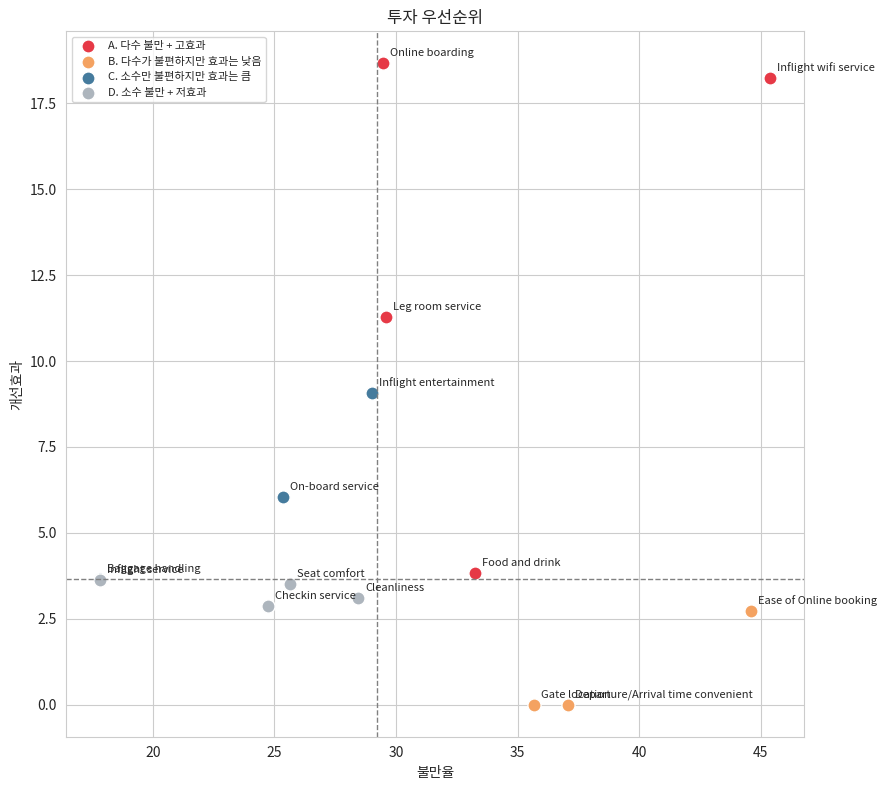

,불만율(%),개선효과(%p),구분
Online boarding,29.45,18.66,A. 다수 불만 + 고효과
Inflight wifi service,45.39,18.23,A. 다수 불만 + 고효과
Leg room service,29.58,11.28,A. 다수 불만 + 고효과
Food and drink,33.24,3.82,A. 다수 불만 + 고효과
Ease of Online booking,44.60,2.73,B. 다수가 불편하지만 효과는 낮음
Departure/Arrival time convenient,37.09,-7.63,B. 다수가 불편하지만 효과는 낮음
Gate location,35.67,-3.04,B. 다수가 불편하지만 효과는 낮음
Inflight entertainment,29.00,9.08,C. 소수만 불편하지만 효과는 큼
On-board service,25.36,6.03,C. 소수만 불편하지만 효과는 큼
Baggage handling,17.83,3.66,C. 소수만 불편하지만 효과는 큼


In [166]:
import matplotlib.pyplot as plt

matrix_df['개선효과_clip'] = matrix_df['개선효과(%p)'].clip(lower=0)
med_u = matrix_df['불만율(%)'].median()
med_e = matrix_df['개선효과_clip'].median()

def quadrant(row):
    high_u = row['불만율(%)'] >= med_u
    high_e = row['개선효과_clip'] >= med_e
    if high_u and high_e:
        return 'A. 다수 불만 + 고효과'
    elif high_u and not high_e:
        return 'B. 다수가 불편하지만 효과는 낮음'
    elif not high_u and high_e:
        return 'C. 소수만 불편하지만 효과는 큼'
    else:
        return 'D. 소수 불만 + 저효과'

matrix_df['구분'] = matrix_df.apply(quadrant, axis=1)

fig, ax = plt.subplots(figsize=(9, 8))

quad_colors = {
    'A. 다수 불만 + 고효과': '#e63946',
    'B. 다수가 불편하지만 효과는 낮음': '#f4a261',
    'C. 소수만 불편하지만 효과는 큼': '#457b9d',
    'D. 소수 불만 + 저효과': '#adb5bd',
}

for q, sub in matrix_df.groupby('구분'):
    ax.scatter(sub['불만율(%)'], sub['개선효과_clip'], s=90, color=quad_colors[q], label=q, edgecolor='white')
    for name, row in sub.iterrows():
        ax.annotate(name, (row['불만율(%)'], row['개선효과_clip']), fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axvline(med_u, color='gray', linestyle='--', linewidth=1)
ax.axhline(med_e, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('불만율')
ax.set_ylabel('개선효과')
ax.set_title('투자 우선순위')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('figs/03_priority_matrix.png', dpi=120)
plt.show()

matrix_df.sort_values(['구분', '개선효과_clip'], ascending=[True, False])[['불만율(%)', '개선효과(%p)', '구분']]

- **group A**. — **온라인 탑승수속 ,기내 와이파이, 다리 공간, 식음료**: 많은 승객이 불편해하고, 개선 시 효과도 크다.
- **group B.** — **온라인 예매 편의성, 출발/도차 시간 편의성, 게이트 위치**: 불만율은 높지만, 점수를 올려도 만족도 개선으로 잘 이어지지 않는다. 예산을 투입해도 체감 효과가 작을 가능성이 크다
- **group C.** — **기내 엔터테인먼트, 기내 서비스 만족도, 비행 중 서비스 만족도**: 불편을 느끼는 승객 비율 자체는 중간 이하지만, 개선했을 때 만족도 상승 폭이 크다.
- **group D.** — **좌석 편의성, 수하물 처리, 청결도, 체크인 서비스**: 불만율도 낮고 효과도 낮아 우선순위가 낮다.


## 6. 예측 모델을 이용한 투자 전후 시뮬레이션

A그룹의 `Online boarding`,`Inflight wifi service`에 투자해 점수를 끌어올렸다고 가정하고, 예측 모델로 투자 전후의 전체 만족률이 얼마나 달라지는지 시뮬레이션한다.

비교를 위해 D그룹의`Cleanliness`만 개선했을 때도 해본다

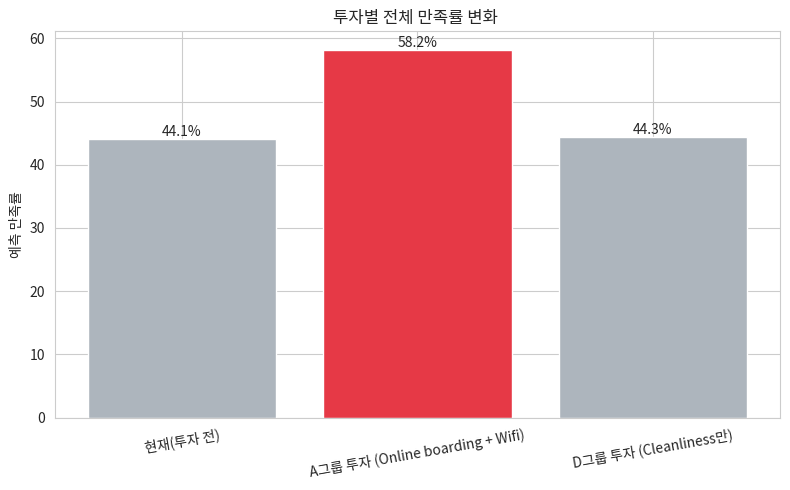

,시나리오,예측 만족률(%),상승폭(%p)
0,현재(투자 전),44.07,0.00
1,A그룹 투자 (Online boarding + Wifi),58.19,14.12
2,D그룹 투자 (Cleanliness만),44.33,0.26


In [167]:
baseline_rate = rf.predict(X_test).mean()

# 가정 1: A그룹(Online boarding, Inflight wifi) 4점 미만인 승객을 4점으로 개선
X_sim_A = X_test.copy()
for col in ['Online boarding', 'Inflight wifi service']:
    X_sim_A[col] = X_sim_A[col].clip(lower=4)
rate_A = rf.predict(X_sim_A).mean()

# 가정 2: D그룹(Cleanliness)만 4점으로 개선 (비교용)
X_sim_D = X_test.copy()
X_sim_D['Cleanliness'] = X_sim_D['Cleanliness'].clip(lower=4)
rate_D = rf.predict(X_sim_D).mean()

sim_result = pd.DataFrame({
    '시나리오': ['현재(투자 전)', 'A그룹 투자 (Online boarding + Wifi)', 'D그룹 투자 (Cleanliness만)'],
    '예측 만족률(%)': [baseline_rate*100, rate_A*100, rate_D*100],
})
sim_result['상승폭(%p)'] = sim_result['예측 만족률(%)'] - baseline_rate*100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sim_result['시나리오'], sim_result['예측 만족률(%)'], color=['#adb5bd', '#e63946', '#adb5bd'])
ax.set_ylabel('예측 만족률')
ax.set_title('투자별 전체 만족률 변화 ')
for bar, val in zip(bars, sim_result['예측 만족률(%)']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%', ha='center')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('figs/04_simulation.png', dpi=120)
plt.show()

sim_result.round(2)


**가상 시뮬레이션 결과**: A그룹(`Online boarding`, `Inflight wifi service`)을 개선하면 전체 예측 만족률이 약 **13~14%** 상승하는 반면, D그룹의(`Cleanliness`)만 개선하면 상승폭은 1%도 되지 않는다. 이는 우선순위가 실제 예측 모델 상에서도 뚜렷한 차이를 만든다는 것을 보여준다.

## 7. 결론

1. **분포**: 승객은 물리적 편의성과 디지털/예약 편의성 두 축을 기준으로 나뉘며, 만족/불만족은 특히 물리적 편의성 축을 따라 갈린다.
2. **중요도**: 전체적으로는 Online boarding, Inflight wifi service, Leg room service가 만족도 예측에 가장 중요한 변수다.
3. **투자 우선순위**: 각각의 항목을 단순 중요도가 아니라 '불만율 × 개선효과'로 나누어 보면,
   - Online boarding, Inflight wifi service, Leg room service, Food and drink: **최우선 투자 대상**이고,
   - Ease of Online booking, Departure/Arrival time convenient, Gate location: **불만은 많지만 투자 효과가 낮은 항목** (우선순위에서 밀려야 할 것 같음 )
   - Inflight entertainment, On-board service, Inflight service: **불만율은 높지 않지만 개선 효과가 큰 항복**
4. **시뮬레이션**: 예측 모델로 확인한 결과, 최우선 투자 항목을 개선하면 전체 만족률이 약 13~14%p 상승하는 반면, 후순위 항목 개선은 1%p 미만의 효과에 그친다.

> **항공사는 한정된 예산을 Online boarding, Inflight wifi service, Leg room service에 우선 투자하고, Inflight entertainment 같은 항목을 2차 투자 대상으로 검토해야 한다. 반면 Ease of Online booking이나 Departure/Arrival time convenient처럼 불만은 많지만 개선 효과가 낮은 항목은, 겉보기 불만율만 보고 투자 우선순위를 매기면 안될 것으로 보인다.**

### 한계
- '개선효과'는 Random Forest의 Partial Dependence 방식으로 추정한 값으로, 실제 항공사가 해당 항목을 개선했을 때의 인과적 효과와는 차이가 있을 수 있다 (상관관계 기반 추정의 한계가 있음).
